In [2]:
print('hi')

hi


In [1]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras import datasets

In [2]:
(X_train,y_train) , (X_test,y_test) = datasets.mnist.load_data()

print(f'Train of X : {X_train.shape}, Train of y : {y_train.shape}')
print(f'Test of X : {X_test.shape}, test of y : {y_test.shape}')

Train of X : (60000, 28, 28), Train of y : (60000,)
Test of X : (10000, 28, 28), test of y : (10000,)


In [3]:
X_train = X_train / 255.0
X_test = X_test / 255.0

In [4]:
X_train_flatten = X_train.reshape(len(X_train),28 * 28)
X_test_flatten = X_test.reshape(len(X_test),28 * 28)

In [5]:
model = tf.keras.Sequential([
    layers.Dense(10,input_shape=(784,),activation='sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics= ['accuracy']
)

model.fit(X_train_flatten,y_train,epochs=10)

model.evaluate(X_test_flatten,y_test)

c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8769 - loss: 0.4694
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9147 - loss: 0.3039
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9205 - loss: 0.2834
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9241 - loss: 0.2729
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9258 - loss: 0.2667
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9272 - loss: 0.2619
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9285 - loss: 0.2585
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9299 - loss: 0.2555
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9299 - loss: 0.2531
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9309 - loss: 0.2508
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9270 - loss: 0.2658


[0.2658234238624573, 0.9269999861717224]

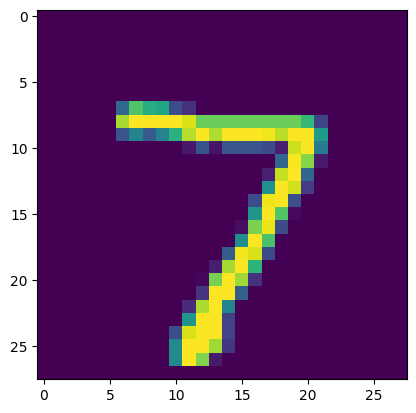

In [12]:
import matplotlib.pyplot as plt
import numpy as np

plt.imshow(X_test[0])

In [ ]:
y_predicted = model.predict(X_test_flatten)
np.argmax(y_predicted[0])



ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32, 784), dtype=float32). Expected shape (None, 28, 28), but input has incompatible shape (32, 784)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32, 784), dtype=float32)
  • training=False
  • mask=None
  • kwargs=<class 'inspect._empty'>

In [14]:

y_predicted = model.predict(X_test)
np.argmax(y_predicted[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


7

In [15]:
y_predicted_lable = [np.argmax(i) for i in y_predicted]

y_predicted_lable[:10]

[7, 2, 1, 0, 4, 1, 4, 9, 5, 9]

In [16]:
cm =  tf.math.confusion_matrix(labels= y_test,predictions= y_predicted_lable)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 968,    0,    1,    0,    1,    2,    2,    3,    2,    1],
       [   0, 1122,    5,    1,    0,    1,    2,    1,    3,    0],
       [   2,    1, 1006,    3,    2,    0,    1,    3,   13,    1],
       [   0,    0,    4,  987,    2,    3,    0,    6,    4,    4],
       [   0,    0,    5,    0,  966,    2,    2,    1,    1,    5],
       [   2,    0,    0,    7,    1,  872,    3,    0,    4,    3],
       [   8,    3,    2,    1,    5,    8,  925,    0,    6,    0],
       [   2,    3,    6,    4,    4,    0,    0, 1000,    4,    5],
       [   7,    0,    2,    5,    6,    5,    1,    4,  939,    5],
       [   2,    2,    0,    5,   10,    4,    0,    6,    2,  978]])>

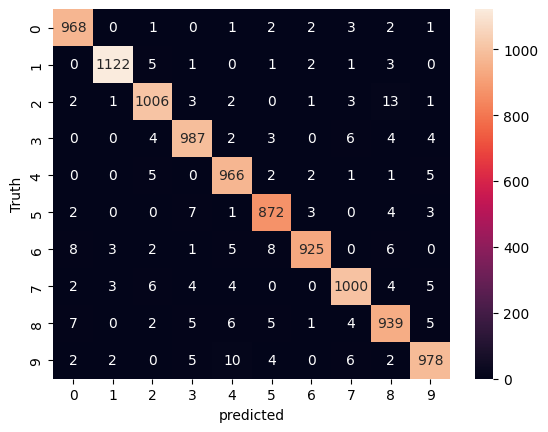

In [17]:
import seaborn as sns

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('Truth')
plt.show()

In [11]:
model = tf.keras.Sequential([
    layers.Flatten(input_shape = (28,28)),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train,y_train,epochs=10)

model.evaluate(X_test,y_test)

c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9174 - loss: 0.2930
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9589 - loss: 0.1405
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9693 - loss: 0.1039
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9751 - loss: 0.0815
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9794 - loss: 0.0668
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9827 - loss: 0.0563
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9855 - loss: 0.0478
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9873 - loss: 0.0416
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9894 - loss: 0.0356
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9906 - loss: 0.0311
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9763 - loss: 0.0873


[0.08729715645313263, 0.9763000011444092]

In [ ]:
import seaborn as sns

sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('predicted')
plt.ylabel('Truth')
plt.show()

In [27]:
from PIL import Image

img = Image.open('digit1.png').convert('L')

img = img.resize((28,28))

img = np.array(img)/255.0

img = img.reshape(1,28,28,1)

prediction = model.predict(img)
print("Predicted digit:", np.argmax(prediction))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Predicted digit: 5


In [1]:
import tensorflow as tf
from tensorflow.keras import layers,models

In [2]:
model = models.Sequential([
    layers.Conv2D(filters=1,activation='relu',input_shape=(4,4,1),kernel_size=(2,2))
])

model.summary()

c:\Users\EATSK\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 3, 3, 1)        │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (20.00 B)

 Trainable params: 5 (20.00 B)

 Non-trainable params: 0 (0.00 B)

In [3]:
import numpy as np

# input image
image = np.array([
    [1,2,3,0],
    [4,5,6,1],
    [7,8,9,2],
    [1,2,3,4]
])

# reshape to match CNN input
image = image.reshape(1,4,4,1)

# run model
output = model.predict(image)

print(output)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 346ms/step
[[[[0.        ]
   [0.16390157]
   [4.9137344 ]]

  [[0.74932194]
   [1.0420321 ]
   [7.384719  ]]

  [[0.5027261 ]
   [0.795436  ]
   [2.373907  ]]]]


In [1]:
print('hi')

hi


In [ ]:
class my_nn:
    import numpy as np
    def __init__(self):
        self.w1=1
        self.w2=1
        self.bais=1

    def gradient_descent(self,x_feartur1,x_feartur2,y_train,epochs):

        for i in range(epochs):
            price =x_feartur1*self.w1 +x_feartur2 *self.w2 +self.bais

            error = (y_train[i] - price)**2

            loss = len(y_train)/np.sum(error)




In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

n = 200
X = np.linspace(-3, 3, n).reshape(-1, 1)
y = 2 * X.ravel() - 0.3 + 0.7 * np.random.randn(n)

w, b = 0.0, 0.0
lr = 0.05
epochs = 200
losses = []

for _ in range(epochs):
    preds = w * X.ravel() + b
    err = preds - y
    loss = (err**2).mean() / 2
    losses.append(loss)
    dw = (X.ravel() * err).mean()
    db = err.mean()
    w -= lr * dw
    b -= lr * db

    print(preds)

# plt.figure()
# plt.plot(losses, color="green")
# plt.title("Linear Regression — Loss (MSE)")
# plt.xlabel("Epoch")
# plt.ylabel("Loss")
# plt.grid(True)
# plt.show()

# plt.figure()
# plt.scatter(X, y, color="lightgreen")
# idx = np.argsort(X.ravel())
# plt.plot(X[idx], (w * X + b)[idx], color="green", linewidth=2)
# plt.title("Linear Regression — Fitted Line")
# plt.xlabel("x")
# plt.ylabel("y")
# plt.grid(True)
# plt.show()

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0.]
[-0.91165803 -0.90262145 -0.89358486 -0.88454828 -0.8755117  -0.86647512
 -0.85743854 -0.84840196 -0.83936537 -0.83032879 -0.82129221 -0.81225563
 -0.80321905 -0.79418246 -0.78514588 -0.7761093  -0.76707272 -0.75803614
 -0.74899955 -0.73996297 -0.73092639 -0.72188981 -0.71285323 -0.70381665
 -0.69478006 -0.68574348 -0.6767069  -0.66767032 -0.65863374 -0.64959715
 -0.64056057 -0.63152399 

In [13]:
from sklearn.preprocessing import StandardScaler

x=np.array([[5],[68],[44],[37]])
y=np.array([1,0,1,1])

scaler = StandardScaler()
scaler_x=scaler.fit_transform(x)

scaler_y = scaler.fit_transform(y.reshape(-1,1))

print(scaler_x,scaler_y)

[[-1.48888889]
 [ 1.31111111]
 [ 0.24444444]
 [-0.06666667]] [[ 0.57735027]
 [-1.73205081]
 [ 0.57735027]
 [ 0.57735027]]


In [14]:
import pandas as pd
import numpy as np
from sklearn import preprocessing

In [15]:
df = pd.read_csv('homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [21]:
scaler_x = scaler.fit_transform(df.drop('price',axis=1))
scaler_y = scaler.fit_transform(df['price'].values.reshape(df.shape[0],1))
print(scaler_y)

[[-0.93270651]
 [ 0.96466144]
 [-0.39512283]
 [-0.0903436 ]
 [-0.65301295]
 [-0.95779218]
 [ 1.31632978]
 [ 1.78522091]
 [-0.6764575 ]
 [ 2.06655558]
 [ 0.0737683 ]
 [ 1.43355256]
 [-0.95779218]
 [-0.91090307]
 [ 0.51921487]
 [-0.86401396]
 [-0.72334662]
 [-0.44201194]
 [ 0.54265942]
 [-1.09845952]]


In [3]:
# s=y2-y2/x2-x1

s=(2-4)/(4-8)
s

0.5

In [1]:
print('hi')

hi


In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [5]:
df = pd.read_csv('homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [7]:
s_x = MinMaxScaler()
s_y = MinMaxScaler()

In [8]:
scaler_x = s_x.fit_transform(df.drop('price',axis='columns'))
scaler_y = s_y.fit_transform(df['price'].values.reshape(df.shape[0],1))


In [11]:
def batch_gradient_descent(x,y_true,epochs):
    num_feature = x.shape[1]
    w = np.ones(shape=(num_feature))
    b = 0
    num_sample = x.shape[0]
    
    cost_list = []
    epochs_list = []
    for i in range(epochs):
        y_predicted = np.dot(w,scaler_x.T) + b

        w_gred = -(2/num_sample) * (x.T.dot(y_true - y_predicted))
        b_gred = -(2/num_sample) * np.sum(y_true - y_predicted)

        w = w - 0.01 * w_gred
        b = b - 0.01 * b_gred

        cost = np.mean(np.square(y_true - y_predicted))

        if i % 10 == 0:
            cost_list.append(cost)
            epochs_list.append(i)

    return w, b, epochs_list, cost_list

w, b, epochs_list, cost_list = batch_gradient_descent(scaler_x,scaler_y.reshape(scaler_y.shape[0]),500)


w,b,cost_list



(array([0.70712464, 0.67456527]),
 -0.23034857438407422,
 [0.2768777174681,
  0.1657350702767106,
  0.10212908135956808,
  0.06564235879682483,
  0.04463022365578522,
  0.03245122421764872,
  0.02531733908301049,
  0.021067914076635823,
  0.018470418935235277,
  0.01682165753542818,
  0.01572033146918248,
  0.014937329116527912,
  0.014341749105819085,
  0.013858709977424097,
  0.013445288028074867,
  0.01307679395234498,
  0.012738945874049962,
  0.012423405193086516,
  0.012125230310262438,
  0.011841424159334757,
  0.011570105565415722,
  0.011310036391930275,
  0.011060351609573906,
  0.01082040510470265,
  0.010589681505198628,
  0.01036774566624043,
  0.010154213642862593,
  0.009948735925187004,
  0.009750987675343718,
  0.009560662965348802,
  0.009377471304274593,
  0.009201135478234788,
  0.009031390146006547,
  0.008867980872255632,
  0.008710663416728336,
  0.0085592031755736,
  0.008413374715338713,
  0.008272961365501461,
  0.008137754849850723,
  0.00800755494527638,
  0

In [14]:
def predicted (area,b_room,w,b):
    scaler_x = s_x.fit_transform([[area,b_room]])[0]

    scaled_price =  w[0] * scaler_x[0] + w[1] * scaler_x[1] +b

    return s_y.inverse_transform([[scaled_price]])[0][0]

predicted(2770,3,w,b)

0.9029424581499819